In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# !pip install scikit-optimize

In [4]:
# from skopt import gp_minimize
# from skopt import space

In [5]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [6]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd
dx = (lambd / 40) * k_0

# normalized simulation lengths
substrate_length = (4 * lambd) * k_0
core_length = (1 * lambd) * k_0
cladding_length = (4 * lambd) * k_0

# refractive indices
n_substrate = 1
n_core = 3
n_cladding = 1

In [7]:
study = 'TE'
field_type = 'E'

In [8]:
RIs = [n_substrate, n_core, n_cladding]
lengths = [substrate_length, core_length, cladding_length]

In [9]:
reference_device = devices.SlabWaveguide(RIs, lambd, lengths, study=study, field_type=field_type)

In [15]:
memory_type = torch.device('cpu')
dtype = torch.float64
torch.manual_seed(42)
num_modes = 3

In [16]:
base_model = models.discontinuity_capturing_network(1, 128, num_modes, 2, 'Siren')
optimzer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[3000, 4000, 5000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 17283


In [17]:
device = devices.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, True)

In [18]:
train_agent = trainers.Trainer(dtype, device, memory_type, [samplers.uniform_grid], optimzer, scheduler, dx)

num PDE samples 359
num rayleigh samples 359
iteration 1 loss1 is 9.68756, loss2 is 0.01895, loss3 is 4.46663, loss4 is 0.94351, loss5 is 0.54009, loss6 is 4.75116


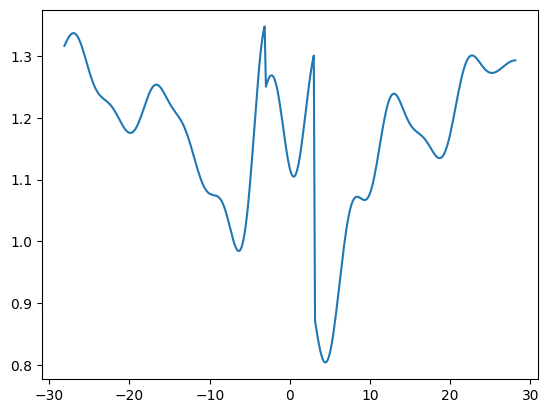

iteration 1001 loss1 is 0.08792, loss2 is 0.00132, loss3 is 0.04062, loss4 is 0.00017, loss5 is 0.00074, loss6 is 0.00284


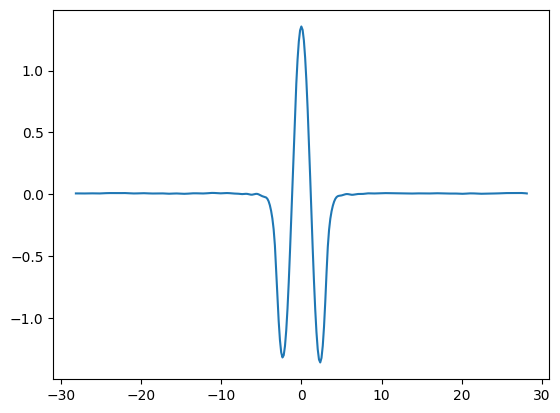

iteration 2001 loss1 is 0.00441, loss2 is 0.0013, loss3 is 0.00157, loss4 is 4e-05, loss5 is 1e-05, loss6 is 0.00114


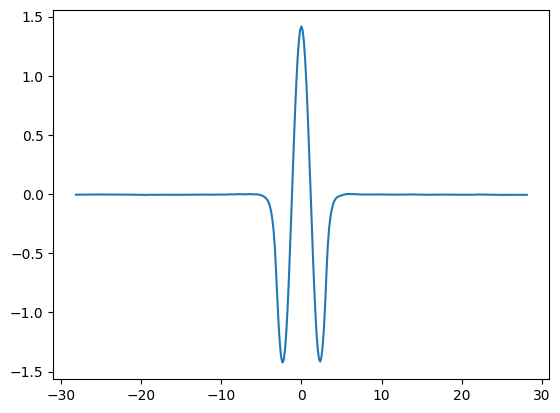

iteration 3001 loss1 is 0.00562, loss2 is 0.00116, loss3 is 0.00186, loss4 is 7e-05, loss5 is 5e-05, loss6 is 0.00016


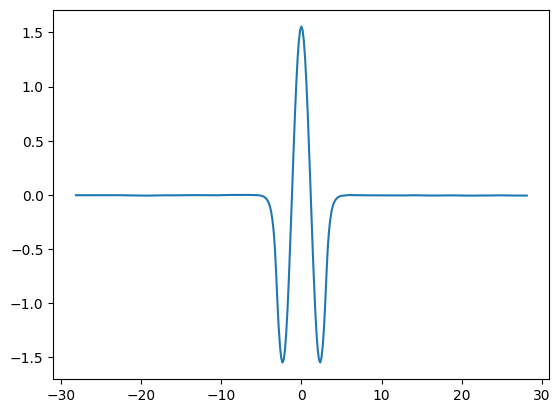

iteration 4001 loss1 is 0.00056, loss2 is 0.00121, loss3 is 0.00017, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


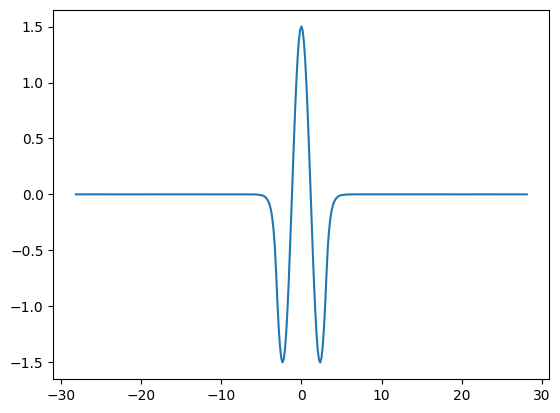

iteration 5001 loss1 is 0.00047, loss2 is 0.0012, loss3 is 0.00014, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


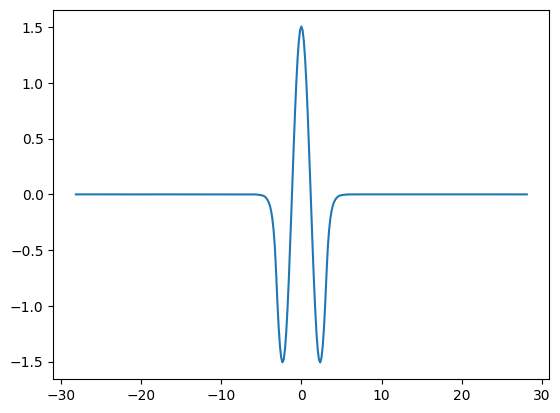

iteration 6001 loss1 is 0.00044, loss2 is 0.0012, loss3 is 0.00013, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


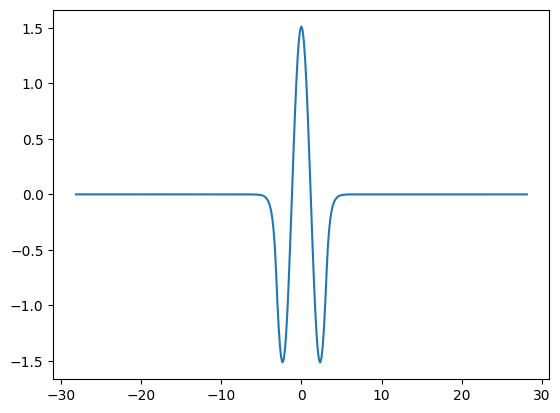

iteration 7001 loss1 is 0.00037, loss2 is 0.00117, loss3 is 0.00011, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


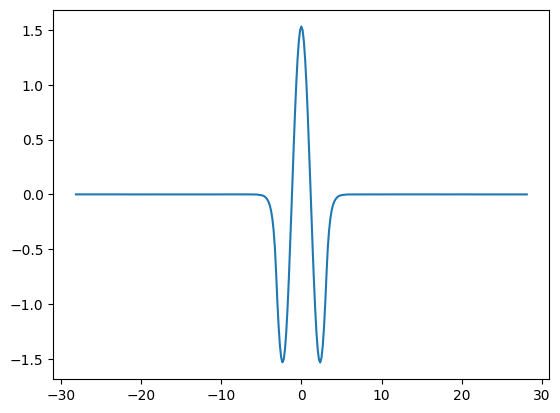

iteration 8001 loss1 is 0.00029, loss2 is 0.0011, loss3 is 9e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


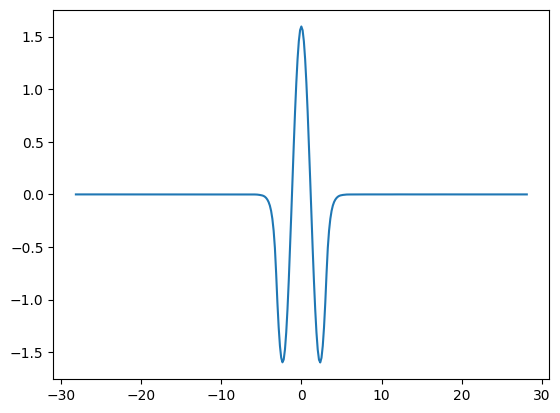

iteration 9001 loss1 is 0.00024, loss2 is 0.00101, loss3 is 7e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


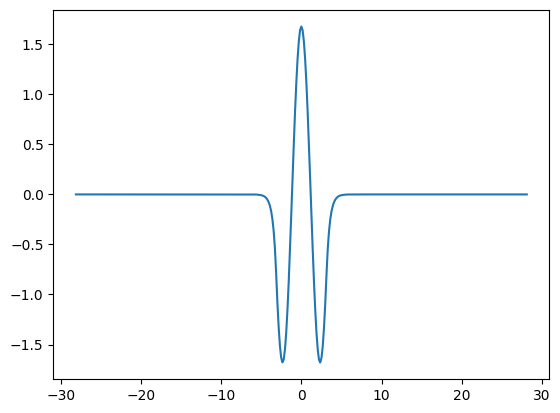

iteration 10001 loss1 is 0.00021, loss2 is 0.00093, loss3 is 6e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


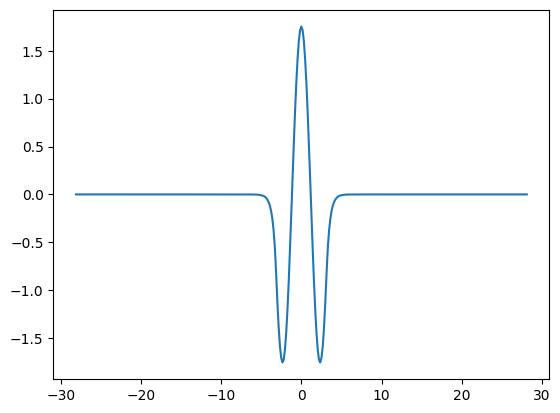

In [19]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=[1/16, 1/16, 16, 1, 1, 1], verbose=1, sample_new=False, plot_solution=True)

# FD Performance

In [20]:
print(dx)

0.15707963267948966


**********
mode errors
**********
relative error for mode 0 is 2.13321%
**********
**********
relative error for mode 1 is 3.48615%
**********
**********
relative error for mode 2 is 4.96352%
**********


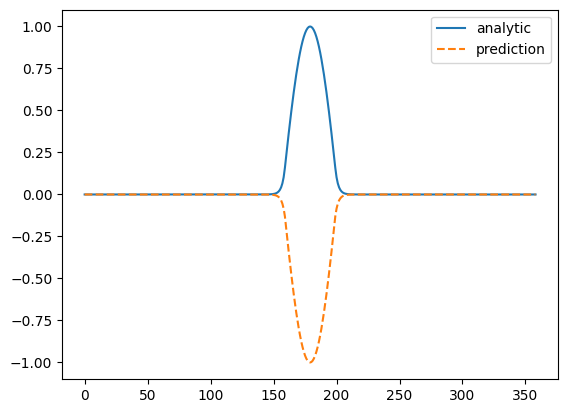

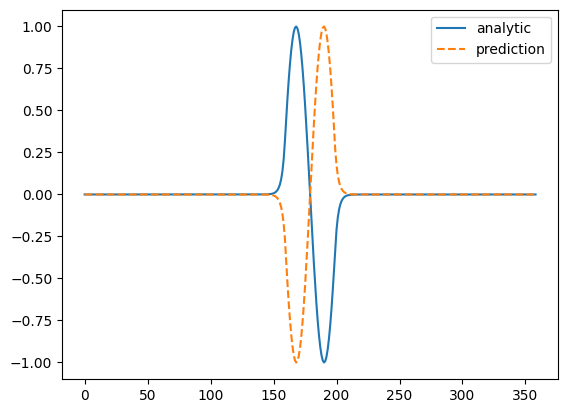

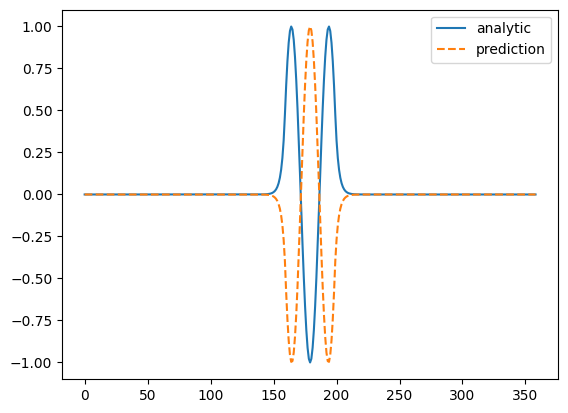

In [21]:
fd_device = devices.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)
_, x, u = fd_device.evaluate(num_modes)
utils.compare_against_analytic(fd_device, x, torch.from_numpy(u));

In [22]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments\TE"

In [31]:
fd_device = devices.SlabWaveguideWithFD(RIs, lambd, lengths, study, field_type, dx)

evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = fd_device.evaluate_analytical(x, num_modes)

if fd_device.study == 'TM' and fd_device.field_type=='E':
  print('adjusting analytic solution for Ex in a TM study')
  eigen_funcs_analytic = eigen_funcs_analytic / fd_device.refractive_index(evaluation_points.reshape(-1), format='numpy')**2

eigen_funcs_analytic /= np.max(np.abs(eigen_funcs_analytic), axis=-1, keepdims=True)

print(eigen_funcs_analytic.shape, eigen_modes_analytic.shape)

np.save(save_folder_path + r"\Planar\Several Modes High Contrast\analytic_EIs.npy", eigen_modes_analytic)
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\analytic_fields.npy", eigen_funcs_analytic)

(3, 359) (3,)


In [32]:
_, x, u = fd_device.evaluate(num_modes)
print(_.shape, u.T.shape)
u = u/np.max(np.abs(u), axis=0, keepdims=True)
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\FD_EIs.npy", _)
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\FD_fields.npy", u.T)

(3,) (3, 359)


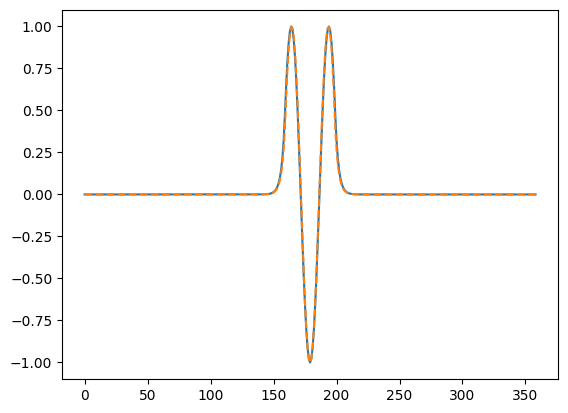

In [33]:
plt.plot(eigen_funcs_analytic[2])
plt.plot(u.T[2], linestyle='--')

In [34]:
mode_errors = []
num_modes = len(u.T)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)

if reference_device.study == 'TM':
  evaluation_pts_error = (torch.mean((torch.from_numpy(evaluation_points).reshape(-1) - x.reshape(-1)) ** 2) / np.mean(
          evaluation_points.reshape(-1) ** 2)) ** 0.5 * 100
  print(f'evalution points are at an error of {round(evaluation_pts_error.item(), 5)}%')

  if reference_device.field_type=='E':
    eigen_funcs_analytic = eigen_funcs_analytic / device.refractive_index(evaluation_points, format='numpy')**2
    eigen_funcs_analytic /= np.linalg.norm(eigen_funcs_analytic, axis=-1, keepdims=True)

# NN Performance

**********
mode errors
**********
relative error for mode 0 is 0.1567%
**********
**********
relative error for mode 1 is 0.22477%
**********
**********
relative error for mode 2 is 0.23973%
**********


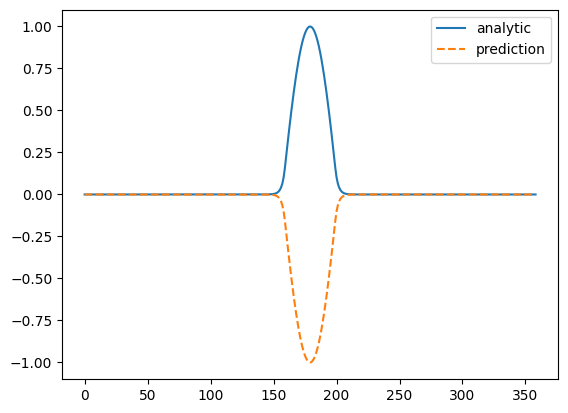

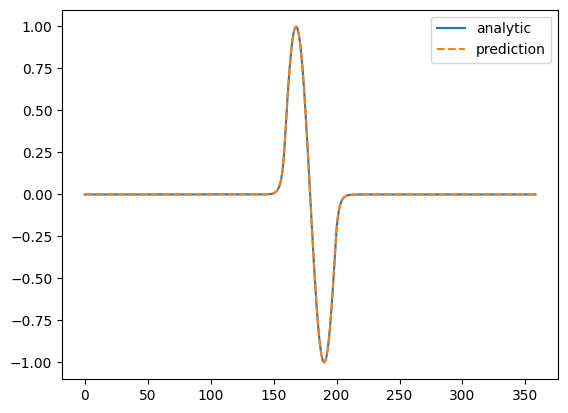

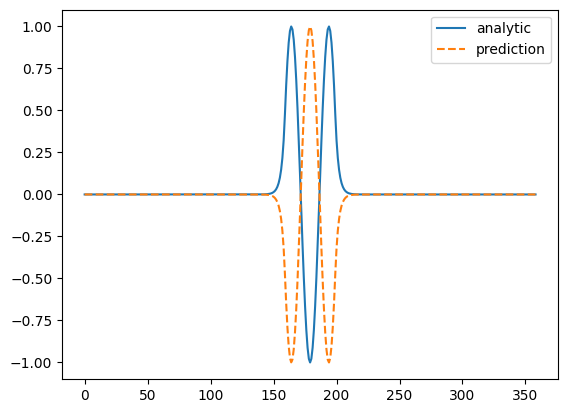

In [27]:
augmented_x = torch.cat((torch.from_numpy(evaluation_points).reshape(-1, 1), device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)
predictions = device.underlying_model(augmented_x)
prediction_normed = predictions.detach().cpu() / torch.max(torch.abs(predictions.detach().cpu()), dim=0, keepdims=True)[0]

utils.compare_against_analytic(reference_device, x, prediction_normed.detach().cpu());

In [28]:
x_tensor = torch.from_numpy(x)
x_tensor.requires_grad = True
x_augmented = torch.cat((x_tensor.reshape(-1, 1), device.refractive_index(torch.from_numpy(x).reshape(-1, 1), format='torch')**2), dim=-1)
NN_EI = [device.calculate_eigen_value(x_augmented.to(memory_type), 0).item()**(1/2), device.calculate_eigen_value(x_augmented.to(memory_type), 1).item()**(1/2), device.calculate_eigen_value(x_augmented.to(memory_type), 2).item()**(1/2)]

_**(1/2), '\n', reference_device.evaluate_analytical(x, 3)[1], '\n', NN_EI

(array([2.96478484, 2.85709667, 2.67011288]),
 '\n',
 array([2.96617486, 2.86268135, 2.68281794]),
 '\n',
 [2.966072067963682, 2.862364450044125, 2.6822257521917])

In [29]:
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\DCNN_EIs.npy", NN_EI)
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\DCNN_fields.npy", prediction_normed.T.numpy())

(3,)
(3, 359)


[]

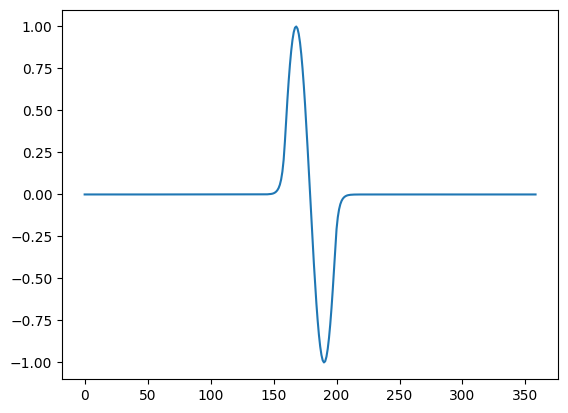

In [30]:
test = np.load(save_folder_path + r"\Planar\Several Modes High Contrast\DCNN_EIs.npy")
print(test.shape)
test = np.load(save_folder_path + r"\Planar\Several Modes High Contrast\DCNN_fields.npy")
print(test.shape)
plt.plot(test[1]);
plt.plot()

number of trainable parameters 17155
num PDE samples 359
num rayleigh samples 359
iteration 1 loss1 is 8.53328, loss2 is 0.00428, loss3 is 2.83807, loss4 is 2.76261, loss5 is 0.40325, loss6 is 0.0


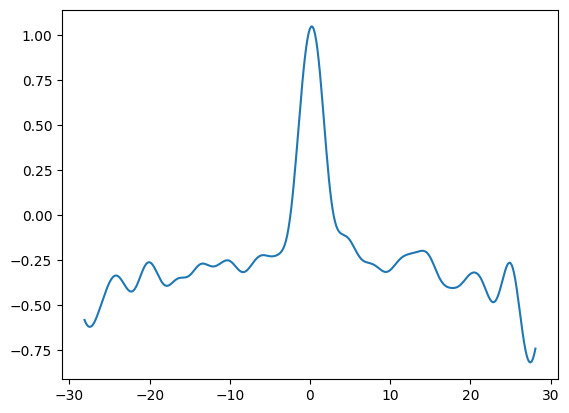

iteration 1001 loss1 is 0.09957, loss2 is 0.00697, loss3 is 0.02733, loss4 is 0.00173, loss5 is 0.00063, loss6 is 0.0


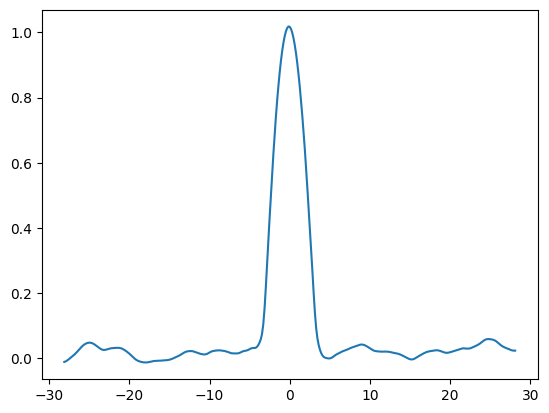

iteration 2001 loss1 is 0.00412, loss2 is 0.01663, loss3 is 0.00154, loss4 is 7e-05, loss5 is 0.0, loss6 is 0.0


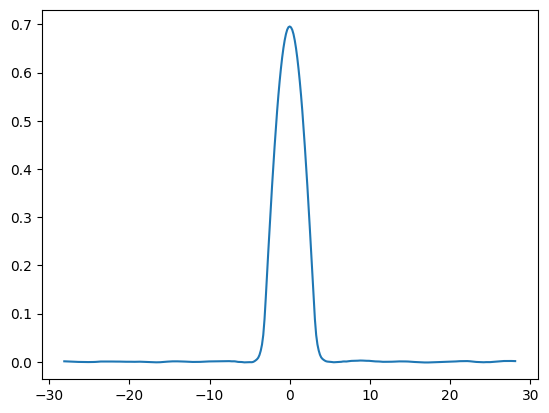

iteration 3001 loss1 is 0.00661, loss2 is 0.01209, loss3 is 0.00211, loss4 is 0.00039, loss5 is 0.0001, loss6 is 0.0


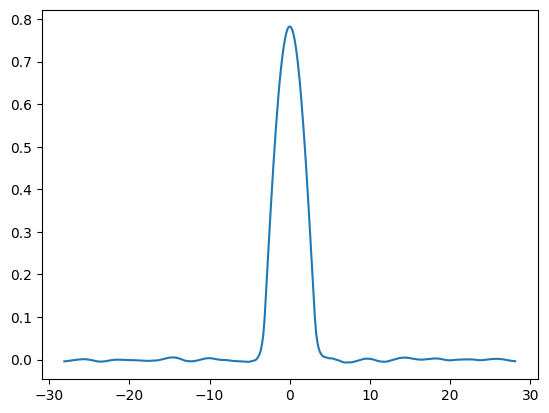

iteration 4001 loss1 is 0.00178, loss2 is 0.00682, loss3 is 0.00064, loss4 is 0.0, loss5 is 1e-05, loss6 is 0.0


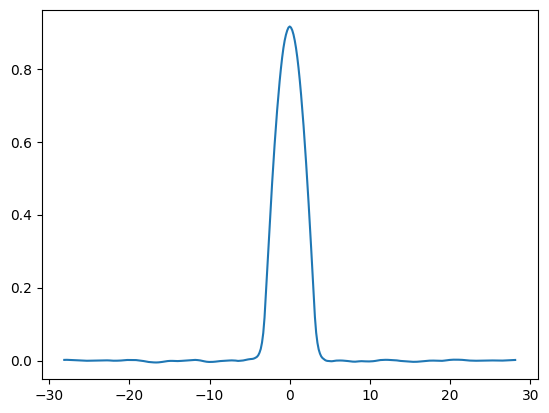

iteration 5001 loss1 is 0.00123, loss2 is 0.00436, loss3 is 0.00039, loss4 is 1e-05, loss5 is 0.0, loss6 is 0.0


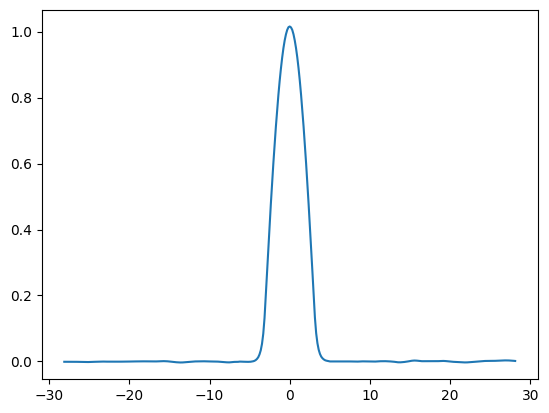

iteration 6001 loss1 is 0.00027, loss2 is 0.00297, loss3 is 0.00011, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


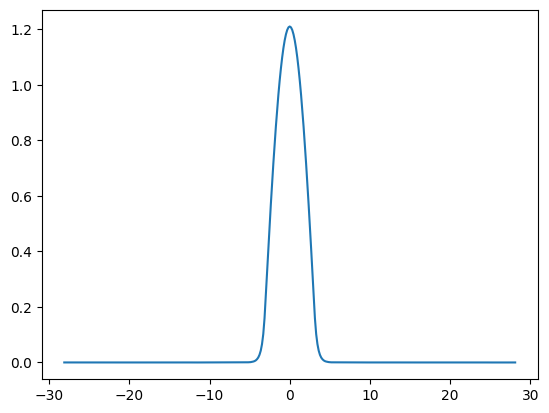

iteration 7001 loss1 is 0.0002, loss2 is 0.00256, loss3 is 8e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


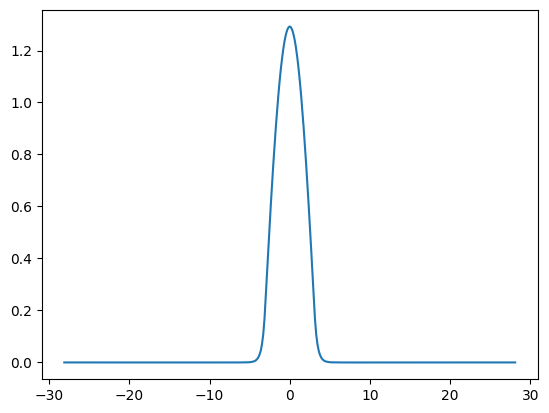

iteration 8001 loss1 is 0.00018, loss2 is 0.00238, loss3 is 8e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


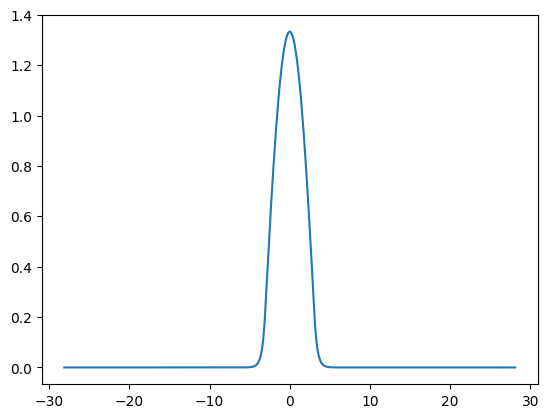

iteration 9001 loss1 is 0.00016, loss2 is 0.00204, loss3 is 7e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


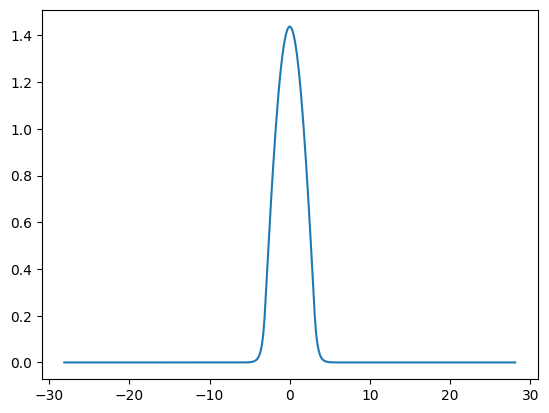

iteration 10001 loss1 is 0.00013, loss2 is 0.00162, loss3 is 5e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


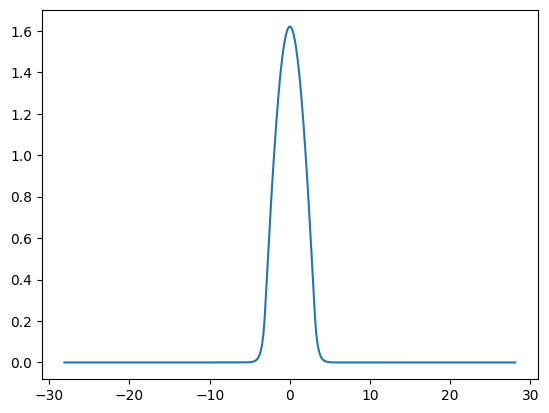

iteration 11001 loss1 is 0.0001, loss2 is 0.00136, loss3 is 4e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


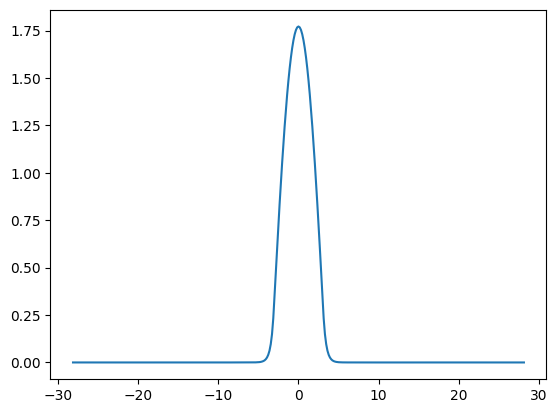

iteration 12001 loss1 is 9e-05, loss2 is 0.0012, loss3 is 3e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


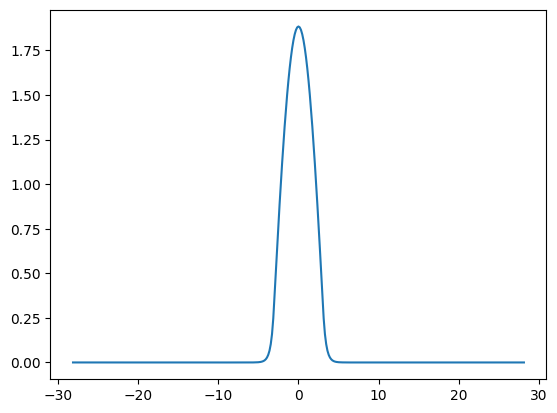

iteration 13001 loss1 is 7e-05, loss2 is 0.00109, loss3 is 3e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


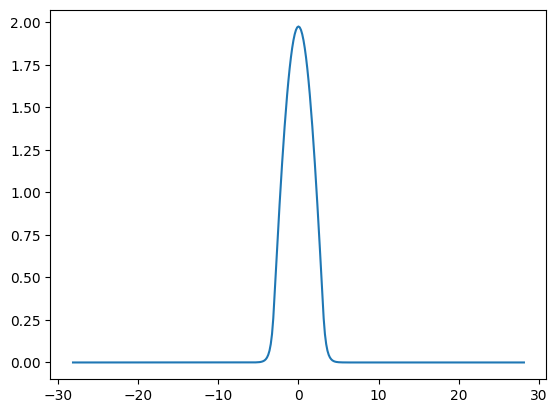

iteration 14001 loss1 is 6e-05, loss2 is 0.001, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


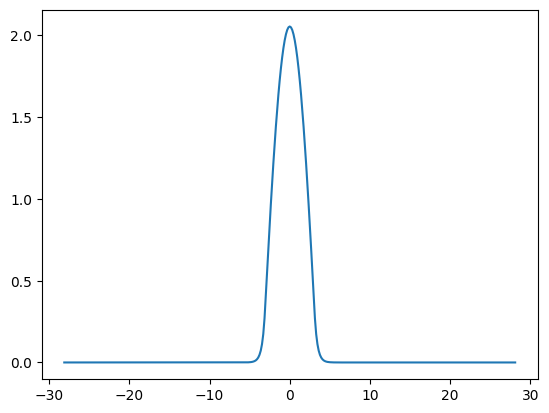

iteration 15001 loss1 is 6e-05, loss2 is 0.00093, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


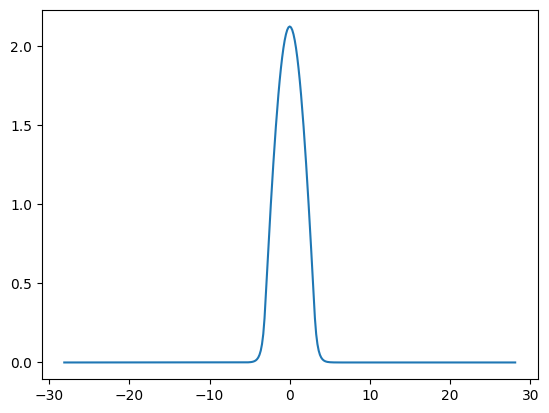

iteration 16001 loss1 is 6e-05, loss2 is 0.00088, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


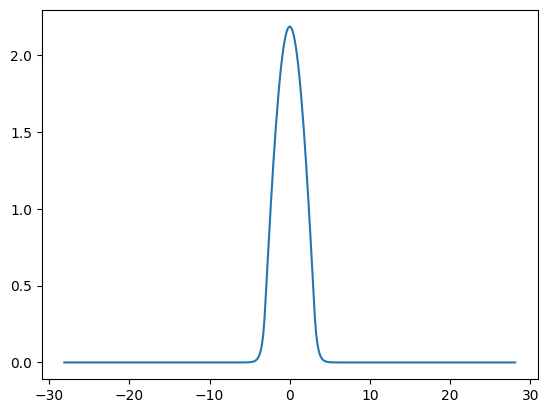

iteration 17001 loss1 is 5e-05, loss2 is 0.00083, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


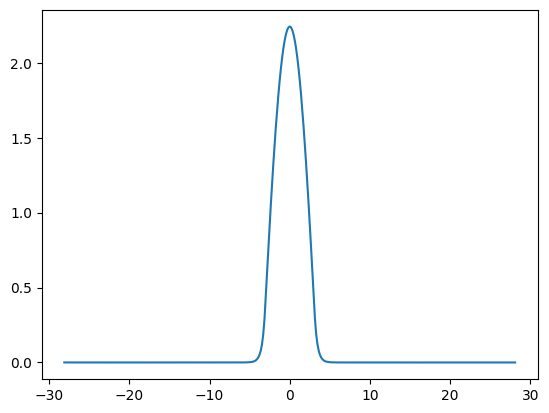

iteration 18001 loss1 is 5e-05, loss2 is 0.00079, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


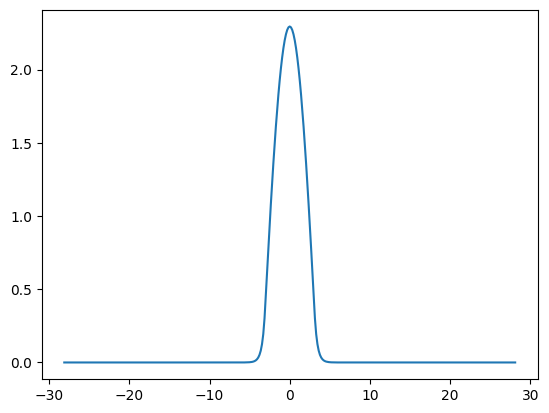

iteration 19001 loss1 is 5e-05, loss2 is 0.00076, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


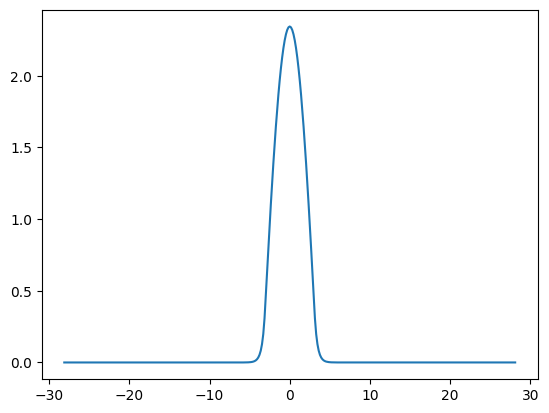

iteration 20001 loss1 is 5e-05, loss2 is 0.00073, loss3 is 2e-05, loss4 is 0.0, loss5 is 0.0, loss6 is 0.0


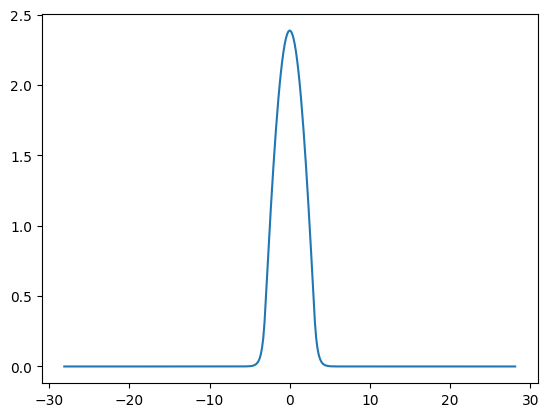

In [37]:
torch.manual_seed(42)

base_model = models.vanilla_network(1, 128, num_modes, 2, 'Siren')
optimzer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[5000, 6000, 7000], gamma=0.2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))
device = devices.SlabWaveguideWithPINNs(RIs, lambd, lengths, study, field_type, base_model, False)
train_agent = trainers.Trainer(dtype, device, memory_type, [samplers.uniform_grid], optimzer, scheduler, dx)
loss_history, rayleigh_history, mode_errors_list = train_agent.train(20001, num_modes, weights=[1/8, 1/32, 10, 1/8, 1, 1], verbose=1, sample_new=False, plot_solution=True)

**********
mode errors
**********
relative error for mode 0 is 3.52741%
**********
**********
relative error for mode 1 is 4.95558%
**********
**********
relative error for mode 2 is 2.18897%
**********


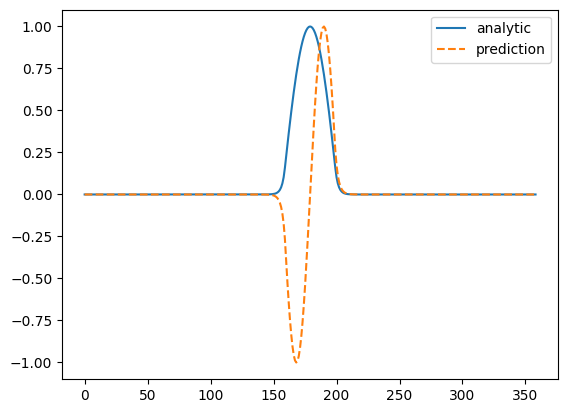

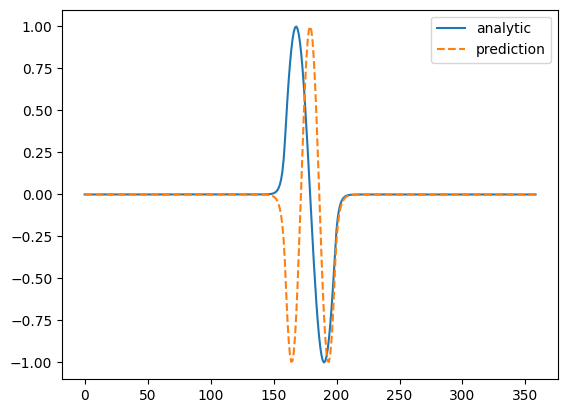

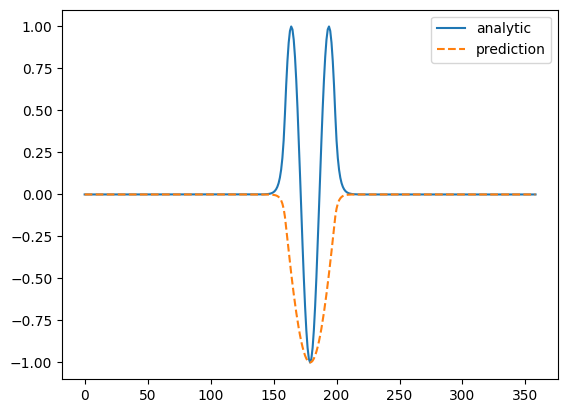

In [39]:
_, x, u = fd_device.evaluate(num_modes)
evaluation_points, eigen_modes_analytic, eigen_funcs_analytic = reference_device.evaluate_analytical(x, num_modes)
# augmented_x = torch.cat((torch.from_numpy(x)reshape(-1, 1), device.refractive_index(torch.from_numpy(evaluation_points).reshape(-1, 1), format='torch')**2), dim=-1).to(memory_type)

predictions = device.underlying_model(torch.from_numpy(evaluation_points).reshape(-1, 1))
prediction_normed = predictions.detach().cpu() / torch.max(torch.abs(predictions.detach().cpu()), dim=0, keepdims=True)[0]

utils.compare_against_analytic(reference_device, evaluation_points, -prediction_normed.detach().cpu());

In [40]:
evaluation_points_tensor = torch.from_numpy(evaluation_points).reshape(-1, 1)
evaluation_points_tensor.requires_grad = True
NN_EI = [device.calculate_eigen_value(evaluation_points_tensor.to(memory_type), 0).item()**(1/2), device.calculate_eigen_value(evaluation_points_tensor.to(memory_type), 1).item()**(1/2), device.calculate_eigen_value(evaluation_points_tensor.to(memory_type), 2).item()**(1/2)]
print(NN_EI)

[2.856623253026675, 2.6683632260259396, 2.9647087610419534]


In [41]:
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\FCNN_EIs.npy", NN_EI)
np.save(save_folder_path + r"\Planar\Several Modes High Contrast\FCNN_fields.npy", prediction_normed.T)